In [149]:
import mediapy as media
import zarr

from wm.utils import load_vae
from wm.utils.obs import normalise_obs, unnormalise_obs

z = zarr.open_group("../data/random_data", mode="r")
vae, _ = load_vae("../experiments/vae")


In [150]:
from numpy import ndarray

ep_ix = 1005
obs_dset: zarr.Array = z["obs"]  # type: ignore


def show_episode_reconstruction(ep_ix: int, fps: int = 30):
    episode: ndarray = obs_dset[ep_ix]  # type: ignore

    episode_norm = normalise_obs(episode)
    reconstructed = vae(episode_norm)  # type: ignore
    reconstructed = unnormalise_obs(reconstructed)  # type: ignore

    media.show_videos(
        [episode, reconstructed],
        titles=["Ground Truth", "Reconstructed"],
        height=64 * 4,
        width=64 * 4,
        fps=fps,
    )


In [170]:
show_episode_reconstruction(240, fps=30)

Ground Truth This browser does not support the video tag.,Reconstructed This browser does not support the video tag.


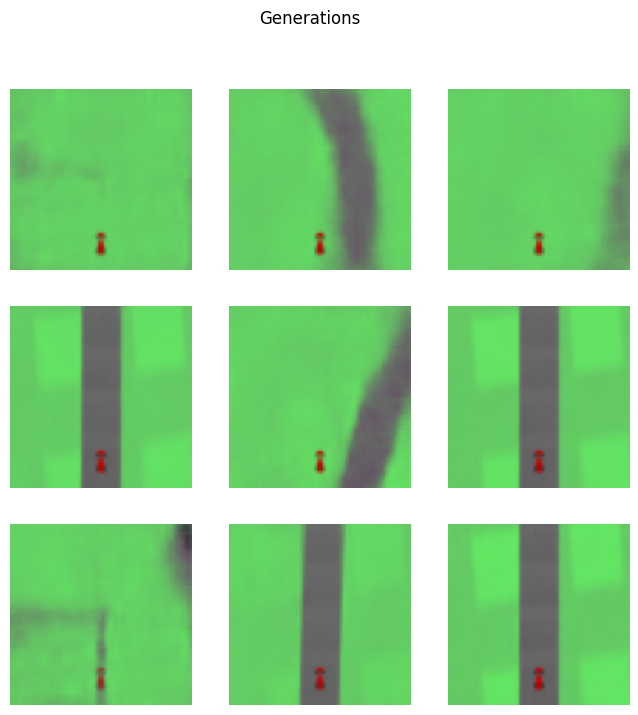

In [169]:
import jax
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3)
fig.set_size_inches(8, 8)

offset = 3
for seed in range(9):
    z = jax.random.normal(jax.random.key(seed + offset), shape=(32,))

    row, col = divmod(seed, 3)
    axes[row, col].imshow(unnormalise_obs(vae.decode(z)))
    axes[row, col].axis(False)

fig.suptitle("Generations")
plt.show()